# Time Series

In [ ]:
import os
import cv2
import pandas as pd
import shutil
import tempfile
import numpy as np
from PIL import Image
from glob import glob
from google.colab import userdata
import matplotlib.pyplot as plt
import json
import joblib

In [ ]:
import pandas as pd
from datetime import datetime

def extract_time_features(df: pd.DataFrame, time_columns: list = None) -> pd.DataFrame:
    """
    Extracts time-based features from specified columns in a DataFrame.
    If time_columns is not provided, it attempts to infer time columns
    by checking common time-related column names.

    Args:
        df (pd.DataFrame): The input DataFrame.
        time_columns (list, optional): A list of column names containing time data.
                                        If None, common time-related column names will be checked.

    Returns:
        pd.DataFrame: The DataFrame with new time feature columns.
    """

    df_copy = df.copy()

    # Common time-related column name patterns for inference
    if time_columns is None:
        possible_time_col_patterns = [
            'time', 'date', 'timestamp', 'datetime', 'created_at',
            'updated_at', 'ts', 'event_time', 'start_time', 'end_time'
        ]
        inferred_time_columns = [
            col for col in df_copy.columns
            if any(pattern in col.lower() for pattern in possible_time_col_patterns)
        ]
        if not inferred_time_columns:
            print("Warning: No time columns specified and no common time-related columns found. "
                  "Returning original DataFrame.")
            return df_copy
        time_columns = inferred_time_columns
        print(f"Inferred time columns: {time_columns}")

    # Possible time formats to try for robust parsing
    # Ordered from most specific/common to more general
    possible_time_formats = [
        "%Y-%m-%d %H:%M:%S.%f",  # 2025-07-05 13:42:29.123456
        "%Y-%m-%d %H:%M:%S",    # 2025-07-05 13:42:29
        "%Y-%m-%dT%H:%M:%S.%fZ",# ISO 8601 with Z (UTC)
        "%Y-%m-%dT%H:%M:%S",    # ISO 8601 without Z
        "%Y/%m/%d %H:%M:%S",    # 2025/07/05 13:42:29
        "%d-%m-%Y %H:%M:%S",    # 05-07-2025 13:42:29
        "%m/%d/%Y %I:%M:%S %p", # 07/05/2025 01:42:29 PM
        "%d/%m/%Y %H:%M",       # 05/07/2025 13:42
        "%Y-%m-%d",             # 2025-07-05
        "%d-%m-%Y",             # 05-07-2025
        "%m/%d/%Y",             # 07/05/2025
        "%H:%M:%S",             # 13:42:29
        "%H:%M",                # 13:42
        "%I:%M %p"              # 01:42 PM
    ]

    for col in time_columns:
        if col not in df_copy.columns:
            print(f"Warning: Column '{col}' not found in DataFrame. Skipping.")
            continue

        # Convert to datetime, coercing errors to NaT (Not a Time)
        # We try multiple formats with errors='coerce' to handle mixed formats
        df_copy[f'{col}_dt'] = pd.to_datetime(df_copy[col], errors='coerce', infer_datetime_format=True)

        # Drop rows where conversion failed for this column, or handle as NaT
        # For simplicity in feature extraction, we'll proceed with NaT values
        # If a column is entirely NaT after conversion, it's probably not a time column
        if df_copy[f'{col}_dt'].isnull().all() and not df_copy[col].isnull().all():
            print(f"Warning: Column '{col}' could not be converted to datetime. Skipping feature extraction for this column.")
            df_copy = df_copy.drop(columns=[f'{col}_dt'])
            continue

        # Extract features
        dt_col = df_copy[f'{col}_dt'].dt
        df_copy[f'{col}_year'] = dt_col.year
        df_copy[f'{col}_month'] = dt_col.month
        df_copy[f'{col}_day'] = dt_col.day
        df_copy[f'{col}_hour'] = dt_col.hour
        df_copy[f'{col}_minute'] = dt_col.minute
        df_copy[f'{col}_second'] = dt_col.second
        df_copy[f'{col}_dayofweek'] = dt_col.dayofweek # Monday=0, Sunday=6
        df_copy[f'{col}_dayofyear'] = dt_col.dayofyear
        df_copy[f'{col}_weekofyear'] = dt_col.isocalendar().week.astype(int)
        df_copy[f'{col}_quarter'] = dt_col.quarter
        df_copy[f'{col}_is_weekend'] = dt_col.dayofweek.isin([5, 6]).astype(int)
        df_copy[f'{col}_season'] = (dt_col.month % 12 + 3) // 3 # Simple season mapping
        df_copy[f'{col}_is_month_start'] = dt_col.is_month_start.astype(int)
        df_copy[f'{col}_is_month_end'] = dt_col.is_month_end.astype(int)
        df_copy[f'{col}_is_quarter_start'] = dt_col.is_quarter_start.astype(int)
        df_copy[f'{col}_is_quarter_end'] = dt_col.is_quarter_end.astype(int)
        df_copy[f'{col}_is_year_start'] = dt_col.is_year_start.astype(int)
        df_copy[f'{col}_is_year_end'] = dt_col.is_year_end.astype(int)

        # Optional: Add cyclical features (sin/cos transformations for hour, dayofweek, etc.)
        # These are useful for models to understand cyclical patterns without arbitrary breaks
        # Example for hour
        df_copy[f'{col}_hour_sin'] = np.sin(2 * np.pi * dt_col.hour / 24)
        df_copy[f'{col}_hour_cos'] = np.cos(2 * np.pi * dt_col.hour / 24)

    return df_copy

# For cyclical features
import numpy as np

if __name__ == "__main__":
    # Example Usage:
    data = {
        'event_time_str1': [
            '2023-01-01 10:30:00',
            '2023-01-02 14:05:30',
            '2023-01-03 08:00:00',
            '2023-01-04 23:59:59',
            'invalid_time',
            None
        ],
        'creation_date_str': [
            '2024-05-15',
            '2024/06/20',
            '10/01/2024', # MM/DD/YYYY
            '25-12-2023', # DD-MM-YYYY
            '2024-01-01 00:00:00.123456',
            '2024-01-01T00:00:00Z'
        ],
        'timestamp_unix': [
            1672534800,  # 2023-01-01 10:00:00 UTC
            1672621200,  # 2023-01-02 10:00:00 UTC
            1672707600,
            1672794000,
            None,
            1672880400
        ],
        'some_other_column': [1, 2, 3, 4, 5, 6]
    }
    df = pd.DataFrame(data)

    print("Original DataFrame:")
    print(df)
    print("\n" + "="*50 + "\n")

    # Example 1: Inferring time columns automatically
    print("Extracting features with inferred time columns:")
    df_transformed_inferred = extract_time_features(df.copy())
    print(df_transformed_inferred.head())
    print(df_transformed_inferred.columns)
    print("\n" + "="*50 + "\n")

    # Example 2: Specifying time columns explicitly
    print("Extracting features with specified time columns:")
    df_transformed_explicit = extract_time_features(df.copy(), time_columns=['creation_date_str', 'timestamp_unix'])
    print(df_transformed_explicit.head())
    print(df_transformed_explicit.columns)
    print("\n" + "="*50 + "\n")

    # Example 3: DataFrame with only one time column and a known complex format
    df_single_col = pd.DataFrame({
        'complex_time': [
            '2023-03-01T10:00:00.123456Z',
            '2023-03-02 11:30:15',
            '2023-03-03 09:00:00.123', # Less precise
            'Invalid Date Here'
        ]
    })
    print("Extracting features from a single complex time column:")
    df_transformed_single = extract_time_features(df_single_col.copy())
    print(df_transformed_single)
    print("\n" + "="*50 + "\n")

In [ ]:
def download_kaggle(kaggle_command="kaggle competitions download -c liver-fibrosis-severity-prediction"):

  # Get Kaggle Key
  kaggle_username = userdata.get("KAGGLE_USER")
  kaggle_key = userdata.get("KAGGLE_KEY")
  if not kaggle_username or not kaggle_key:
      print("Error: Kaggle_USERNAME or Kaggle_KEY not found in Colab Secrets.")
      return

  # Write the credentials to ~/.kaggle/kaggle.json
  kaggle_dir = os.path.expanduser("~/.kaggle")
  os.makedirs(kaggle_dir, exist_ok=True)

  # Create JSON
  kaggle_json_path = os.path.join(kaggle_dir, "kaggle.json")
  with open(kaggle_json_path, "w") as f:
      f.write(f'{{"username":"{kaggle_username}","key":"{kaggle_key}"}}')
  os.chmod(kaggle_json_path, 0o600)

  try:
      os.system(kaggle_command)
      print("\n--- Download complete! ---")
      os.system("ls -la")
      os.system("unzip -o '*.zip' && rm -f *.zip")
      os.system("ls -la")

  except Exception as e:
      print(f"An error occurred during download: {e}")




def timeseries_features_lag(df: pd.DataFrame,
                            list_features_target_cols: list[str],
                            list_lags: list[int]):
  """
  Time Series Features Lagging :
  input -> df and list of target columns
  return df with lagged features (nan will not be removed, please used df.dropna() after)
  """
  df_copy = df.copy()

  for feature_col in list_features_target_cols:
    for lag in list_lags:
      df_copy[f'lag_{feature_col}_{lag}'] = df_copy['target'].shift(lag)

  return df_copy




def time_series_features_rolling(df: pd.DataFrame,
                                 list_features_target_cols: list[str],
                                 list_window_size : list[int],
                                 list_aggregrate_function : list[str]):
  """
  Time Series Features Rolling :
  input ->
  - df
  - features_target_cols : list of target columns
  - window_size : window size for rolling calculations (e.g., [7, 30] for 7-day and 30-day windows).
  - aggregate_function : list of aggregate functions includes ['mean', 'std', 'min', 'max', 'median']
  return df with lagged features (nan will not be removed, please used df.dropna() after)
  """
  df_copy = df.copy()

  for feature_col in list_features_target_cols:
    for window in list_window_size:
      for agg_function in list_aggregrate_function:
        df_copy[f'rolling_{feature_col}_{window}_{agg_function}'] = df_copy['target'].rolling(window=window).agg(agg_function)

  return df_copy




def time_series_features_differencing(df: pd.DataFrame,
                                      list_features_target_cols: list[str],
                                      list_interval: list[int]):
  """
  Time Series Features Differencing:
  input ->
  - df (pd.DataFrame): The input DataFrame. It should have a DatetimeIndex for proper time-series operations,
                        though pandas' .diff() works on numerical indices too.
  - list_features_target_cols (List[str]): List of column names on which to apply differencing.
  - list_interval (List[int]): List of intervals (periods) for differencing (e.g., [1, 7, 12]).

  return ->
  pd.DataFrame: A new DataFrame with the added differenced features.
                NaN values will be present at the beginning of the series due to differencing.
                Please use df.dropna() after this operation if needed.
  """
  df_copy = df.copy()

  for feature_col in list_features_target_cols:
      for interval in list_interval:
          df_copy[f'{feature_col}_diff_{interval}'] = df_copy[feature_col].diff(periods=interval)

  return df_copy




def time_series_features_sin_cos(df: pd.DataFrame):
  """
  REQUIREMENTS : time features -> 'year', 'month', 'day', 'hour', 'minute', 'second'
  input ->
  - df (pd.DataFrame): The input DataFrame. It should have a DatetimeIndex for proper time-series operations,
                        though pandas' .diff() works on numerical indices too.
  return ->
  pd.DataFrame: A new DataFrame with the added differenced features.
  """

  df_copy = df.copy()

  # Check if the features are allowed
  if 'month' not in df_copy.columns or 'day' not in df_copy.columns :
    raise ValueError("The input DataFrame must contain 'month' and 'day' columns.")

  # Day of week
  df_copy['day_of_week_sin'] = np.sin(2 * np.pi * df_copy['day_of_week'] / 7)
  df_copy['day_of_week_cos'] = np.cos(2 * np.pi * df_copy['day_of_week'] / 7)

  # Month Sin Cos
  df_copy['month_sin'] = np.sin(2 * np.pi * df_copy['month'] / 12)
  df_copy['month_cos'] = np.cos(2 * np.pi * df_copy['month'] / 12)

  return df_copy



# def time_series_features_day_of_week(df: pd.DataFrame):
#   """
#   REQUIREMENTS : time features -> 'year', 'month', 'day', 'hour', 'minute', 'second'
#   """

#   df_copy = df.copy()

#   df_copy['day_of_week'] = df_copy.

#   return df_copy



# def time_series_features(df: pd.DataFrame):
#   """
#   REQUIREMENTS : time features -> 'year', 'month', 'day', 'hour', 'minute', 'second'
#   input ->
#   - df (pd.DataFrame): The input DataFrame.
#   """
#   df_copy = df.copy()



def tabular_features_one_hot_encoding_train_set(df: pd.DataFrame, features: str, save_path: str):
  """
  One Hot Encoding for Categorical Features and then save the weight
  """
  from sklearn.preprocessing import OneHotEncoder
  import joblib

  # Instance calling one hot encoding
  one_hot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

  # Return as array
  array_encode_feature = one_hot_encoder.fit_transform(
      # array-like of shape (n_samples, n_features)
      X=df[features],
      # array-like of shape (n_samples,) or (n_samples, n_outputs), default=None
      y=None
  )

  # Turn to pandas
  df_encode_feature = pd.DataFrame(array_encode_feature)
  df_copy = pd.concat([df, df_encode_feature], axis=1)

  # Save weight to save_path
  joblib.dump(one_hot_encoder, save_path)

  return df_copy




def tabular_features_one_hot_encoding_test_set(df: pd.DataFrame, features: str, load_path: str):
  """
  One Hot Encoding Test Set using weight from train set, the unknown will be filled with all 0
  """
  from sklearn.preprocessing import OneHotEncoder

  # Instance calling one hot encoding
  one_hot_encoder = joblib.load(load_path)
  encoded_data = one_hot_encoder.transform(df[features])
  encoded_df = pd.DataFrame(encoded_data,
                            columns=one_hot_encoder.get_feature_names_out(features),
                            index=df.index)
  df_encoded = pd.concat([df, encoded_df], axis=1)
  return df_encoded



def tabular_features_one_hot_encoding_train_set_with_imputation(df: pd.DataFrame, features: str, save_path: str):
  """
  One Hot Encoding for Categorical Features and then save the weight
  """
  from sklearn.preprocessing import OneHotEncoder
  # https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html
  from sklearn.impute import SimpleImputer
  from sklearn.pipeline import Pipeline
  import joblib

  # Instance calling one hot encoding
  one_hot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

  one_hot_encoder_pipeline = Pipeline([
      ('imputer', SimpleImputer(strategy='most_frequent')),
      ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
  ])

  # Return as array
  array_encode_feature = one_hot_encoder_pipeline.fit_transform(
      # array-like of shape (n_samples, n_features)
      X=df[features],
      # array-like of shape (n_samples,) or (n_samples, n_outputs), default=None
      y=None
  )

  # Turn to pandas
  df_encode_feature = pd.DataFrame(
      encoded_data=array_encode_feature,
      columns=one_hot_encoder_pipeline.named_steps['onehot'].named_steps['onehot'].get_feature_names_out(features),
      index=df.index
  )
  df_copy = pd.concat([df, df_encode_feature], axis=1)

  # Save weight to save_path
  joblib.dump(one_hot_encoder_pipeline, save_path)

  return df_copy




def tabular_features_one_hot_encoding_test_set_with_imputation(df: pd.DataFrame, features: str, load_path: str):
  """
  One Hot Encoding Test Set using weight from train set, the unknown will be filled with all 0
  """
  from sklearn.preprocessing import OneHotEncoder
  from sklearn.impute import SimpleImputer
  from sklearn.pipeline import Pipeline

  # Instance calling one hot encoding
  one_hot_encoder_pipeline = joblib.load(load_path)

  # Transform Test Set
  encoded_data = one_hot_encoder_pipeline.transform(df[features])
  encoded_df = pd.DataFrame(encoded_data,
                            columns=one_hot_encoder_pipeline.named_steps['onehot'].get_feature_names_out(features),
                            index=df.index)

  df_encoded = pd.concat([df, encoded_df], axis=1)
  return df_encoded




def tabular_features_fill_nan_numerical(df: pd.DataFrame, features: str, strategy: str):
  """
  Fill Mean for Nan Numerical Features
  strategy -> mean, median, most_frequent
  """
  from sklearn.impute import SimpleImputer
  df_columns = SimpleImputer(strategy=strategy)
  df_copy = df.copy()
  df_copy[features] = df_columns.fit_transform(df[features])
  return df_copy


def tabular_features_fill_nan_categirical(df: pd.DataFrame, features: str):
  """
  Fill Most frequency for NaN Categorical Features
  """
  from sklearn.impute import SimpleImputer
  df_columns = SimpleImputer(strategy='most_frequent')
  df_copy = df.copy()
  df_copy[features] = df_columns.fit_transform(df[features])
  return df_copy




def tabular_features_label_encoding_train_set(df: pd.DataFrame, features: str, save_path: str):
  """
  Label Encoding for Categorical Features and then save the weight
  """
  from sklearn.preprocessing import LabelEncoder
  import joblib

  le = LabelEncoder()
  array_encode_feature = le.fit_transform(df[features])
  df_copy = pd.concat([df, pd.DataFrame(array_encode_feature)], axis=1)
  joblib.dump(le, save_path)
  return df_copy



def tabular_features_label_encoding_test_set(df: pd.DataFrame, features: str, save_path: str):
  """
  Label Encoding for Categorical Features for testet
  """
  from sklearn.preprocessing import LabelEncoder
  import joblib

  le = joblib.load(save_path)
  array_encode_feature = le.fit_transform(df[features])
  df_copy = pd.concat([df, pd.DataFrame(array_encode_feature)], axis=1)
  return df_copy





In [ ]:
def visualizer_categorical(df: pd.DataFrame, feature: str):
  """
  Plot Categorical Features
  """
  import seaborn as sns
  import matplotlib.pyplot as plt

  sns.set_style("whitegrid")
  plt.figure(figsize=(10, 6))
  sns.countplot(data=df, x=feature, palette='viridis')
  plt.title(f'Frequency of {feature}')
  plt.xlabel(f'{feature} Category')
  plt.ylabel('Count')
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()


def visualizer_timeseries(df: pd.DataFrame, feature: str):
  """
  Plot Timeseries Features
  """
  import seaborn as sns
  import matplotlib.pyplot as plt

  sns.set_style("whitegrid")
  plt.figure(figsize=(14, 7))
  sns.lineplot(data=df, x=df.index, y=feature, palette='deep')
  plt.title(f'Time Series Plot of {feature}', fontsize=16)
  plt.ylabel(feature, fontsize=12)
  plt.xticks(rotation=45, ha='right')
  plt.grid(True)
  plt.tight_layout()
  plt.show()

# Data Science : Income Prediction

https://www.kaggle.com/competitions/data-science-income-prediction/data

In [ ]:
download_kaggle("kaggle competitions download -c data-science-income-prediction")


--- Download complete! ---


In [ ]:
df_train = pd.read_csv("train.csv")
df_train

/tmp/ipython-input-10-4101288200.py:1: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv("train.csv")


,id,address_role,zip_code,deposit_balance,deposit_incoming,deposit_outgoing,average_loan_24_months,average_outstanding_balance_6_months,children,credit_history_3_years,...,employment_time,employment_industry,family_status,gender,housing_type,income_type,marital_status,max_outstanding_balance_12_months,total_debt,primary_income
0,0,NaN,Unspecified,NaN,NaN,NaN,NaN,780.00,NaN,NaN,...,NaN,NaN,NaN,F,NaN,Retired Pensioner,NaN,9200.0,0.0,30000.0
1,1,NaN,Unspecified,NaN,NaN,NaN,NaN,36017.00,NaN,NaN,...,NaN,NaN,NaN,F,NaN,Salaried Govt,NaN,104754.4,19067.0,59000.0
2,2,NaN,Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,M,NaN,Retired Pensioner,NaN,NaN,18781.0,30000.0
3,3,NaN,Unspecified,NaN,NaN,NaN,NaN,8100.00,NaN,NaN,...,More than five years,Other,Married,F,NaN,Employed,NaN,51800.0,0.0,60000.0
4,4,NaN,Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,More than five years,Other,Married,F,NaN,Salaried Govt,NaN,NaN,0.0,40000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1299995,1299995,NaN,Unspecified,NaN,NaN,NaN,NaN,65571.31,NaN,NaN,...,Less than one year,Education,Married,F,NaN,Salaried Govt,NaN,75040.6,56061.6,70000.0
1299996,1299996,NaN,Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,More than five years,Other,Married,M,NaN,Employed,NaN,NaN,0.0,28000.0
1299997,1299997,NaN,Unspecified,NaN,NaN,NaN,NaN,8530.36,NaN,2.0,...,More than one year,Education,Single,M,NaN,Salaried Govt,NaN,19961.8,15134.4,50000.0
1299998,1299998,NaN,Unspecified,NaN,NaN,NaN,NaN,239373.66,NaN,NaN,...,NaN,NaN,NaN,F,NaN,Retired Pensioner,NaN,312925.8,221552.8,90000.0


In [ ]:
len(df_train['zip_code'].unique())

1336

In [ ]:
pd.DataFrame(df_train['zip_code'].unique())

,0
0,Unspecified
1,NaN
2,35176
3,58275
4,75750
...,...
1331,68552
1332,14542
1333,50083
1334,86576


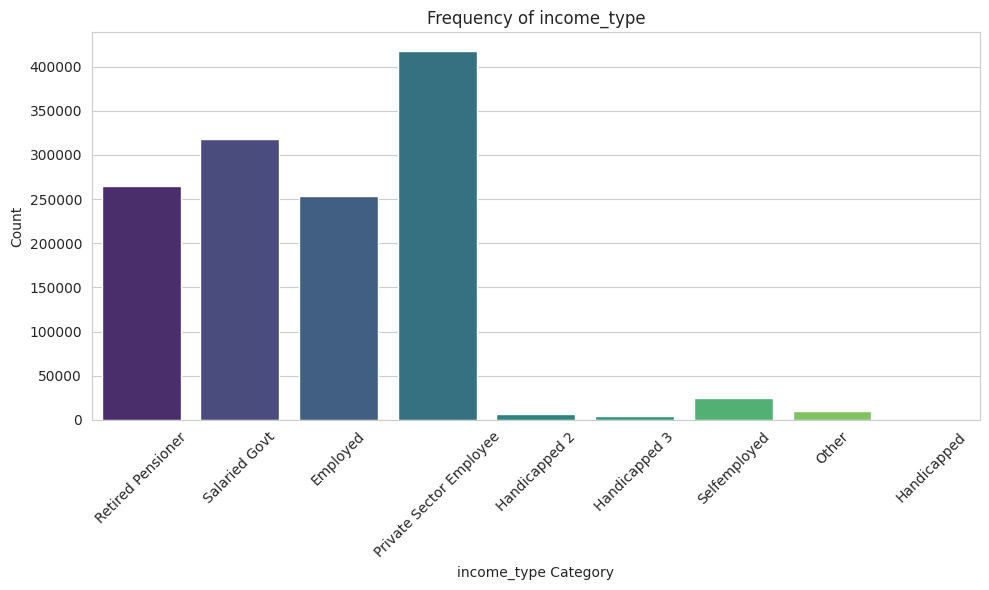

In [ ]:
visualizer_categorical(df_train, 'income_type')

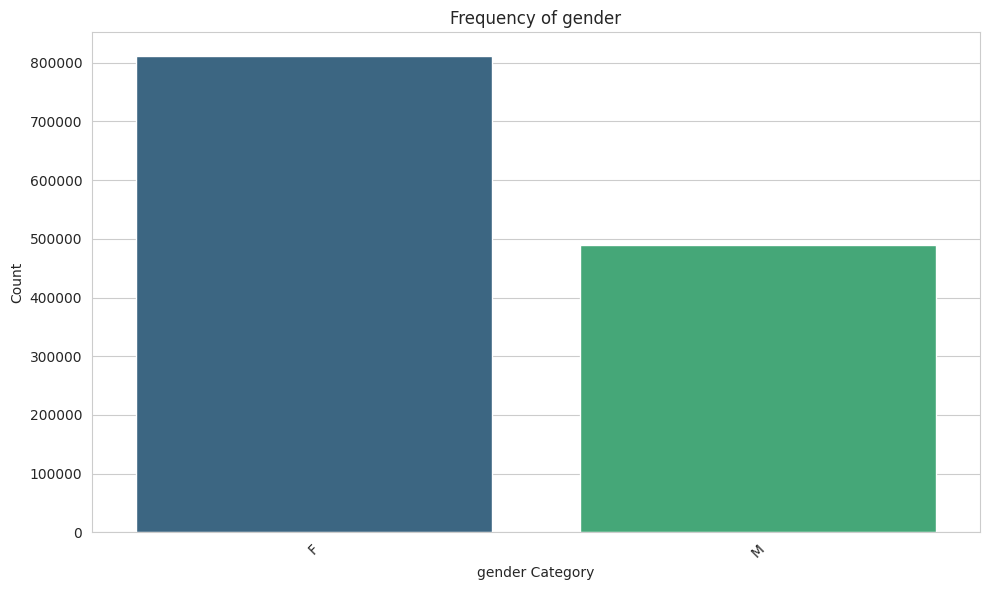

In [ ]:
visualizer_categorical(df_train, 'gender')

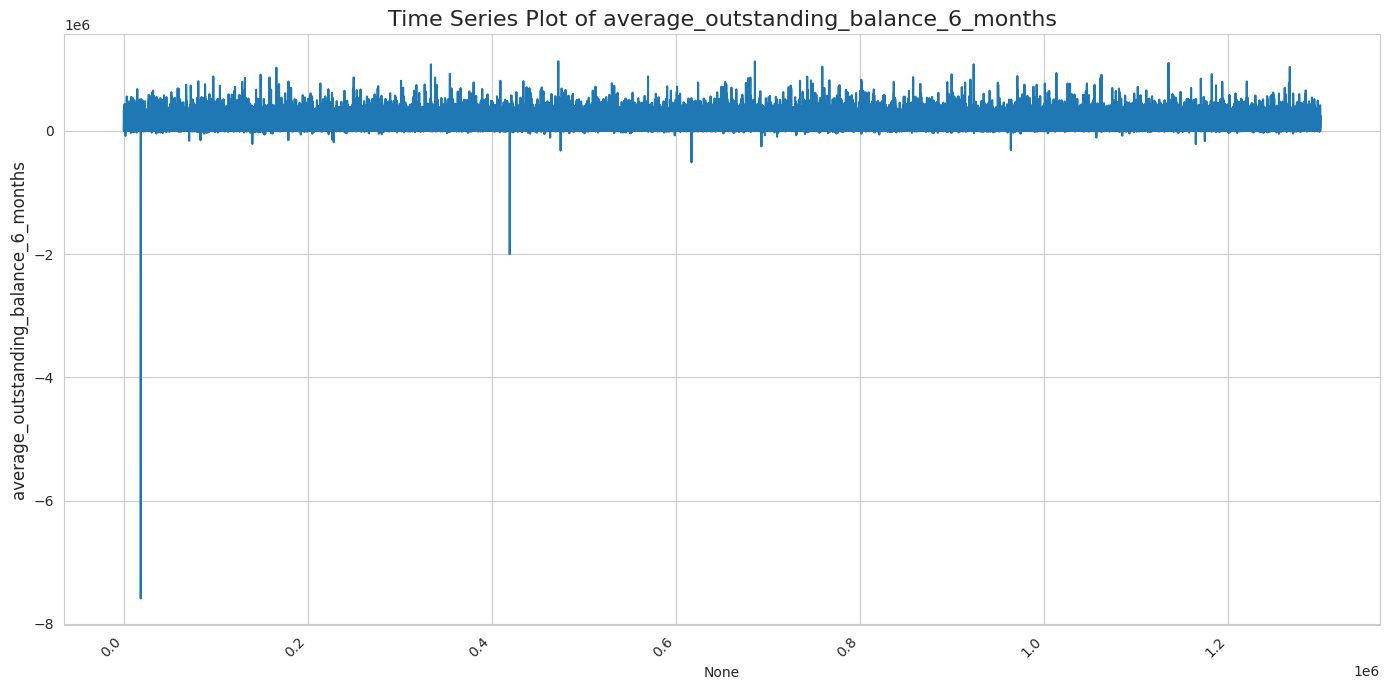

In [ ]:
visualizer_timeseries(df_train, 'average_outstanding_balance_6_months')

/tmp/ipython-input-30-2129116588.py:28: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=df, x=df.index, y=feature, palette='deep')


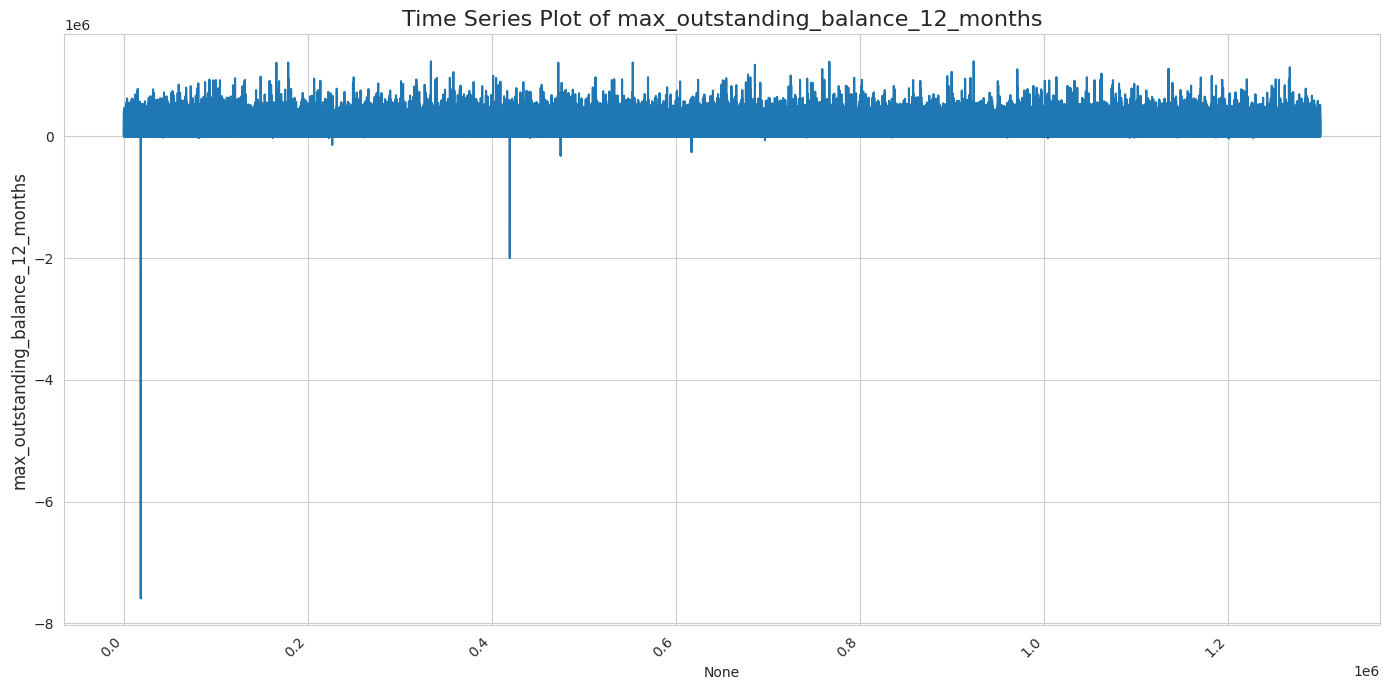

In [ ]:
visualizer_timeseries(df_train, 'max_outstanding_balance_12_months')

In [ ]:
len(df_train['housing_type'].unique())

7